# Sales Data — Exploratory Data Analysis

## Project Objective

The objective of this project is to clean, explore, and analyze a sales dataset in order to identify patterns in products, categories, cities, and revenue.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/orders.csv")


## 1. Data Understanding

In this section, I inspect the dataset structure, columns, data types, missing values, duplicates, and descriptive statistics before performing any transformations.

In [4]:
orders.shape
orders.head()
orders.info()
orders.describe()
orders.isna().sum()
orders.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      16 non-null     int64  
 1   product       16 non-null     object 
 2   category      15 non-null     object 
 3   price         14 non-null     float64
 4   quantity      16 non-null     int64  
 5   customer_age  15 non-null     float64
 6   city          16 non-null     object 
dtypes: float64(2), int64(2), object(3)
memory usage: 1.0+ KB


np.int64(1)

## 2. Data Cleaning

In this section, I handle duplicates, missing values, inconsistent categorical values, potential outliers, and invalid quantities.

In [5]:
clean_orders = orders.drop_duplicates().copy()

clean_orders["category"] = clean_orders["category"].fillna("Accessories")

Headphones_median = clean_orders.loc[
    clean_orders["product"] == "Headphones", "price"].median()
clean_orders["price"] = clean_orders["price"].fillna(Headphones_median)
clean_orders["category"] = clean_orders["category"].str.title()
clean_orders["city"] = clean_orders["city"].str.title()
clean_orders["customer_age"] = clean_orders["customer_age"].fillna(clean_orders["customer_age"].median())

price_Q1 = clean_orders["price"].quantile(0.25)
price_Q3 = clean_orders["price"].quantile(0.75)
price_IQR = price_Q3 - price_Q1
price_lowerBound = price_Q1 - 1.5 * price_IQR
price_upperBound = price_Q3 + 1.5 * price_IQR
clean_orders[(clean_orders["price"] < price_lowerBound) | (clean_orders["price"] > price_upperBound)]
clean_orders = clean_orders.drop(clean_orders.loc[clean_orders["quantity"] <0].index)



## 3. Feature Engineering

Two new features are created for the analysis:

- `revenue`: calculated from the product price and quantity purchased.
- `price_level`: categorizes products into Low, Medium, and High price levels.

In [6]:
clean_orders["revenue"] = clean_orders["price"] * clean_orders["quantity"]

def price_level(x):
    if x < 100:
        return "Low"
    elif 100 <= x <= 600:
        return "Medium"
    return "High"

clean_orders["price_level"] = clean_orders["price"].apply(price_level)


## 4. Exploratory Data Analysis

In this section, I analyze revenue, prices, order frequency, and quantities across products, categories, and cities.

In [7]:
revenue_total = clean_orders["revenue"].sum()
revenue_total_produit = clean_orders.groupby("product")["revenue"].sum()
#produit generant le plus de revenue total
clean_orders.groupby("product")["revenue"].sum().sort_values(ascending=False).head(1)
revenue_total_category = clean_orders.groupby("category")["revenue"].sum()
prix_moyen_category = clean_orders.groupby("category")["price"].mean()
ville_commandes = clean_orders["city"].value_counts()
revenue_total_ville = clean_orders.groupby("city")["revenue"].sum()
#ville generant le plus de revenue
clean_orders.groupby("city")["revenue"].sum().sort_values(ascending=False).head(1)
clean_orders.sort_values("revenue", ascending=False)[
    ["order_id", "product", "city", "price", "quantity", "revenue"]].head(3)
quantite_moyenne_produit = clean_orders.groupby("product")["quantity"].mean()

## 5. Data Visualization

Visualizations are used to examine price distributions, compare revenue across products, identify potential outliers, and explore relationships between numerical variables.

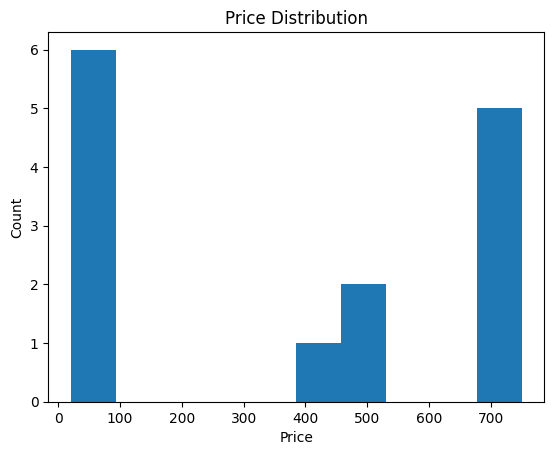

In [8]:
plt.hist(clean_orders["price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

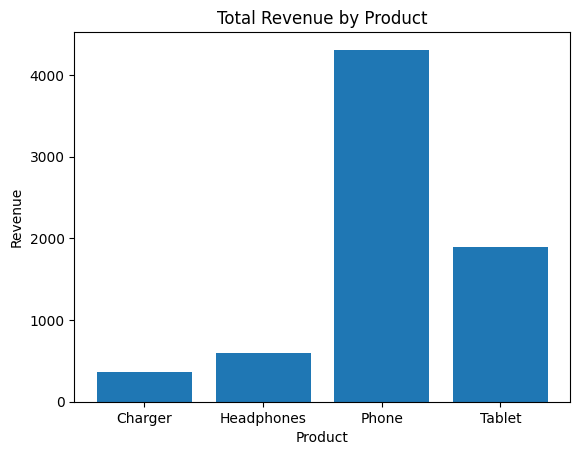

In [9]:
plt.bar(revenue_total_produit.index, revenue_total_produit.values)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Total Revenue by Product")
plt.show()

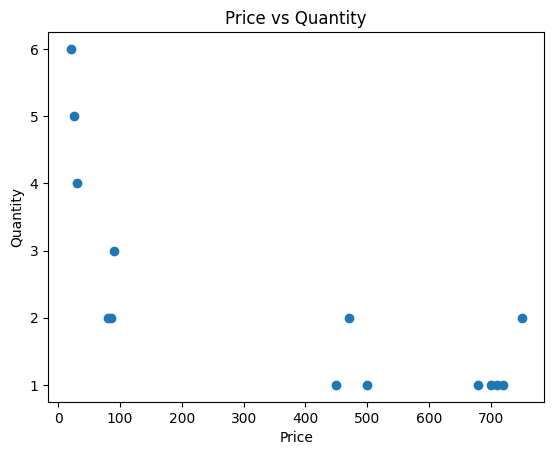

In [10]:
plt.scatter(clean_orders["price"], clean_orders["quantity"])
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show()

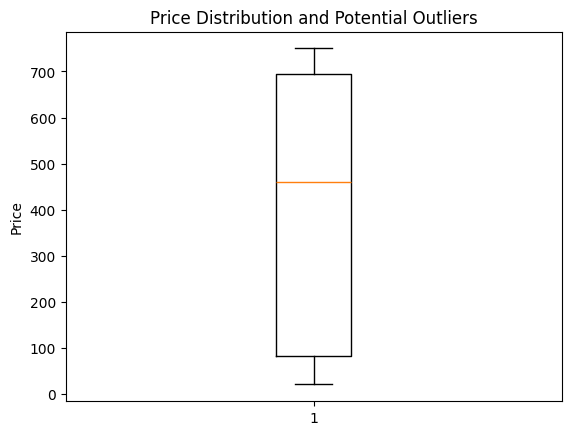

In [11]:
plt.boxplot(clean_orders["price"])
plt.title("Price Distribution and Potential Outliers")
plt.ylabel("Price")
plt.show()

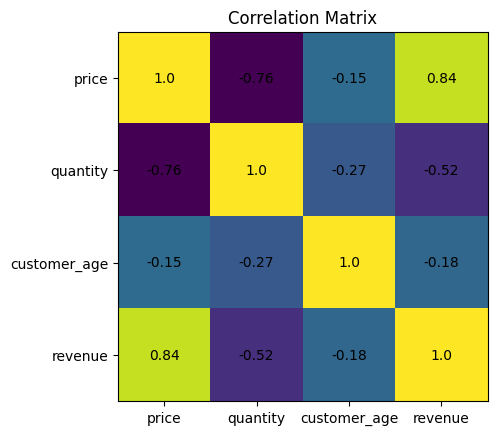

In [12]:

corr = clean_orders.drop(columns=["order_id"]).corr(numeric_only=True)
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.show()

## 6. Key Insights
1. Produits — Revenue
Les Phones génèrent le revenue total le plus élevé du dataset. Cela semble notamment lié à leur prix unitaire relativement élevé et au fait que plusieurs commandes concernent ce produit.

2. Quantités achetées
Les produits les moins chers, notamment les Chargers et les Headphones, ont tendance à être achetés en plus grande quantité que les produits plus chers comme les Phones. Cela suggère une relation négative entre le prix et la quantité achetée dans ce dataset.

3. Catégories
La catégorie Electronics génère nettement plus de revenue que la catégorie Accessories. Cela semble notamment s'expliquer par les prix plus élevés des produits Electronics, qui comprennent les Phones et Tablets, alors que les Accessories contiennent des produits moins chers comme les Chargers et Headphones.

4. Villes
Lyon génère le revenue total le plus élevé. Bien que le nombre de commandes soit assez proche de celui de Paris, l'écart de revenue est important. Cela suggère que le nombre de commandes seul n'explique pas le revenue : la composition des commandes, notamment le type de produit, son prix et la quantité achetée, joue également un rôle important.

5. Relation entre le prix et la quantité achetée
Après le nettoyage des données, on observe que les produits ayant un prix élevé ont tendance à être achetés en plus petites quantités, tandis que les produits moins chers sont généralement achetés en plus grande quantité. Cette relation est visible dans le scatter plot et suggère une association négative entre le prix et la quantité. Cependant, cette observation ne permet pas de conclure à une relation de causalité.